# TabNet — crash severity classification

Pedestrian-crash-severity methodology from Rafe et al. (2024) adapted to the RTA dataset.
Three classes (Slight / Serious / Fatal). Pipeline:

1. Load `data/data_cleaned.csv`, define feature set, train / val / test split.
2. Encode (OrdinalEncoder + StandardScaler) using statistics fit on train only.
3. Optuna hyperparameter search with stratified k-fold CV. SMOTE on the training
   fold only — no leakage into the validation fold.
4. Train final model on full training set (with SMOTE) using best hyperparameters,
   monitor early stopping on the held-out validation set.
5. Test-set evaluation: accuracy, precision, recall, F1, AUC, confusion matrix.
6. Per-class threshold tuning with line plots.
7. SHAP analysis (KernelExplainer) and a sensitivity / post-hoc study.
8. Save model and metrics to `models/` and `outputs/`.

GPU is used for TabNet training when CUDA is available.

Color convention: Fatal = red, Serious = yellow, Slight = green.


## 1. Setup

In [1]:
import json
import logging
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
import optuna
import shap

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
log = logging.getLogger("tabnet")
# SHAP / matplotlib loggers are very chatty at INFO; pin to WARNING.
logging.getLogger("shap").setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

# Reproducibility.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
log.info(f"Device: {DEVICE}")
if DEVICE == "cuda":
    log.info(f"GPU: {torch.cuda.get_device_name(0)}")

# Paths and run config.
ROOT = Path.cwd()
DATA = ROOT / "data" / "data_cleaned.csv"
MODEL_DIR = ROOT / "models"
FIG_DIR = ROOT / "outputs" / "figures"
RESULTS = ROOT / "outputs" / "tabnet_metrics.json"
for p in (MODEL_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

# Hyperparameter search budget. Tune down if iterating quickly.
N_TRIALS = 50
N_FOLDS = 5
MAX_EPOCHS = 200
PATIENCE = 30
BATCH_SIZE = 1024
VBATCH_SIZE = 256
SHAP_BG = 100
SHAP_EVAL = 200

SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]
SEVERITY_COLORS = {"Slight Injury": "#2ca02c", "Serious Injury": "#f1c40f", "Fatal injury": "#d62728"}
SEVERITY_PALETTE = [SEVERITY_COLORS[s] for s in SEVERITY_ORDER]
SEV_SHORT = ["Slight", "Serious", "Fatal"]


/home/thsondev/Projects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
18:55:35 [INFO] Device: cuda
18:55:35 [INFO] GPU: NVIDIA GeForce RTX 5060


## 2. Helpers

`encode()` is the single source of truth for input transformation: OrdinalEncoder
on categoricals (with the +1 shift trick so unknowns map to a reserved 0 slot —
required by TabNet's embedding layer), StandardScaler on numerics. Encoder/scaler
are fit on the training set only and reused for val/test.


In [2]:
def define_features(df: pd.DataFrame):
    """Return (cat_cols, num_cols). The four columns with `_ord` versions are
    dropped from cat_cols because their ordinal numeric counterpart already
    captures the rank ordering, and including both would be redundant."""
    drop_originals_with_ord = [
        "Age_band_of_driver", "Driving_experience",
        "Service_year_of_vehicle", "Educational_level",
    ]
    target_cols = ["Accident_severity", "Severity_code"]
    cat_cols = [c for c in df.select_dtypes(include="object").columns
                if c not in target_cols + drop_originals_with_ord]
    num_cols = [c for c in df.select_dtypes(include=["int64", "float64"]).columns
                if c not in target_cols]
    return cat_cols, num_cols


def encode(df, cat_cols, num_cols, encoder=None, scaler=None, fit=True):
    """OrdinalEncoder + StandardScaler. Shift cat values by +1 so that an
    unknown category (encoded -1 by sklearn) maps into a reserved index 0 slot.
    TabNet's embedding layer requires non-negative indices."""
    cat = df[cat_cols].astype(str).values
    num = df[num_cols].astype(float).values

    if fit:
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        cat_enc = encoder.fit_transform(cat)
        scaler = StandardScaler()
        num_sc = scaler.fit_transform(num)
    else:
        cat_enc = encoder.transform(cat)
        num_sc = scaler.transform(num)

    cat_enc = cat_enc + 1
    X = np.concatenate([cat_enc, num_sc], axis=1).astype(np.float32)
    return X, encoder, scaler


def cat_idxs_dims(encoder, n_cat):
    """TabNet wants categorical positions and per-column cardinalities.
    +1 to dims accounts for the reserved unknown slot."""
    return list(range(n_cat)), [len(c) + 1 for c in encoder.categories_]


In [3]:
def metric_block(y_true, y_pred, y_proba, label=""):
    """Compute and pretty-print the full metric panel for a single test set."""
    out = {
        "accuracy":         accuracy_score(y_true, y_pred),
        "precision_macro":  precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":     recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro":         f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted":      f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr":      roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }
    print(f"=== {label} ===")
    for k, v in out.items():
        print(f"  {k:<18s} {v:.4f}")
    print("\n  classification report:")
    print(classification_report(y_true, y_pred, target_names=SEV_SHORT, zero_division=0))
    return out


def plot_confusion(cm, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(SEV_SHORT); ax.set_yticklabels(SEV_SHORT)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


## 3. Load data and split

Three-way split: 70% train, 15% validation, 15% test. The validation set is
used for early stopping during final training; the test set is held out until
the very end. Stratification preserves the severity distribution across all
three splits — important because Fatal is only 1.3% of the data.


In [4]:
df = pd.read_csv(DATA)
cat_cols, num_cols = define_features(df)
feature_names = cat_cols + num_cols

log.info(f"data shape: {df.shape}")
log.info(f"cat features ({len(cat_cols)}): {cat_cols}")
log.info(f"num features ({len(num_cols)}): {num_cols}")

y = df["Severity_code"].values
print(pd.Series(y).map(dict(enumerate(SEV_SHORT))).value_counts())


18:55:35 [INFO] data shape: (12316, 32)
18:55:35 [INFO] cat features (17): ['Day_of_week', 'Sex_of_driver', 'Vehicle_driver_relation', 'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Cause_of_accident', 'TimeOfDay']
18:55:35 [INFO] num features (9): ['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour', 'RushHour', 'IsWeekend', 'Age_band_of_driver_ord', 'Driving_experience_ord', 'Service_year_of_vehicle_ord', 'Educational_level_ord']


Slight     10415
Serious     1743
Fatal        158
Name: count, dtype: int64


In [5]:
# 70 / 15 / 15 stratified split.
df_trainval, df_test = train_test_split(
    df, test_size=0.15, stratify=y, random_state=SEED)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.1765,    # 0.15 / 0.85
    stratify=df_trainval["Severity_code"].values, random_state=SEED)

log.info(f"train={len(df_train)}  val={len(df_val)}  test={len(df_test)}")

X_train, encoder, scaler = encode(df_train, cat_cols, num_cols, fit=True)
X_val, _, _ = encode(df_val, cat_cols, num_cols, encoder, scaler, fit=False)
X_test, _, _ = encode(df_test, cat_cols, num_cols, encoder, scaler, fit=False)
y_train = df_train["Severity_code"].values
y_val = df_val["Severity_code"].values
y_test = df_test["Severity_code"].values

cat_idxs, cat_dims = cat_idxs_dims(encoder, len(cat_cols))
log.info(f"cat_dims: {cat_dims}")
log.info(f"feature dim: {X_train.shape[1]}")


18:55:35 [INFO] train=8620  val=1848  test=1848
18:55:35 [INFO] cat_dims: [8, 4, 5, 19, 6, 13, 8, 11, 9, 7, 4, 5, 10, 11, 14, 21, 5]
18:55:35 [INFO] feature dim: 26


## 4. Optuna hyperparameter search

Stratified 5-fold CV on the training set. SMOTE is fit on each training fold's
data only — never on the validation fold. The objective is macro-F1 (rather
than accuracy) because Fatal is 65x rarer than Slight and accuracy would be
dominated by the majority class.

Search space follows the original paper, narrowed slightly given the smaller
dataset (12k rows here vs. the larger Utah dataset).


In [6]:
class OptunaProgress:
    """Verbose Optuna callback: per-trial value, running best, and ETA."""
    def __init__(self, total): self.total = total; self.t0 = time.time()

    def __call__(self, study, trial):
        elapsed = time.time() - self.t0
        avg = elapsed / (trial.number + 1)
        eta = avg * (self.total - trial.number - 1)
        log.info(f"trial {trial.number + 1:>2d}/{self.total} | "
                 f"value={trial.value:.4f} | best={study.best_value:.4f} | "
                 f"elapsed={elapsed:>6.1f}s | ETA={eta:>6.1f}s")


def make_tabnet(params, cat_idxs, cat_dims):
    return TabNetClassifier(
        n_d=params["n_d"], n_a=params["n_a"], n_steps=params["n_steps"],
        gamma=params["gamma"],
        n_independent=params["n_independent"], n_shared=params["n_shared"],
        lambda_sparse=params["lambda_sparse"],
        cat_idxs=cat_idxs, cat_dims=cat_dims, cat_emb_dim=params["cat_emb_dim"],
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=params["lr"]),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 10, "gamma": 0.9},
        mask_type=params["mask_type"],
        device_name=DEVICE, verbose=0, seed=SEED,
    )


def objective(trial):
    params = dict(
        n_d=trial.suggest_int("n_d", 8, 64),
        n_a=trial.suggest_int("n_a", 8, 64),
        n_steps=trial.suggest_int("n_steps", 3, 8),
        gamma=trial.suggest_float("gamma", 1.0, 2.0),
        n_independent=trial.suggest_int("n_independent", 1, 5),
        n_shared=trial.suggest_int("n_shared", 1, 5),
        lambda_sparse=trial.suggest_float("lambda_sparse", 1e-5, 1e-2, log=True),
        cat_emb_dim=trial.suggest_int("cat_emb_dim", 1, 4),
        lr=trial.suggest_float("lr", 1e-3, 5e-2, log=True),
        mask_type=trial.suggest_categorical("mask_type", ["entmax", "sparsemax"]),
    )
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_scores = []
    for fold_i, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_va = X_train[tr_idx], X_train[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        # SMOTE on this fold's training portion only.
        sm = SMOTE(random_state=SEED, k_neighbors=5)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

        clf = make_tabnet(params, cat_idxs, cat_dims)
        clf.fit(
            X_tr_sm, y_tr_sm,
            eval_set=[(X_va, y_va)], eval_name=["val"], eval_metric=["accuracy"],
            max_epochs=MAX_EPOCHS, patience=PATIENCE,
            batch_size=BATCH_SIZE, virtual_batch_size=VBATCH_SIZE, drop_last=False,
        )
        preds = clf.predict(X_va)
        fold_scores.append(f1_score(y_va, preds, average="macro"))
    return float(np.mean(fold_scores))


In [7]:
log.info(f"Starting Optuna search: {N_TRIALS} trials, {N_FOLDS}-fold CV")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),
    pruner=optuna.pruners.NopPruner(),
)
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, callbacks=[OptunaProgress(N_TRIALS)])
log.info(f"Optuna done in {time.time() - t0:.1f}s")
log.info(f"best macro-F1: {study.best_value:.4f}")
log.info(f"best params: {study.best_params}")

best_params = dict(study.best_params)


18:55:35 [INFO] Starting Optuna search: 50 trials, 5-fold CV



Early stopping occurred at epoch 83 with best_epoch = 53 and best_val_accuracy = 0.76334

Early stopping occurred at epoch 39 with best_epoch = 9 and best_val_accuracy = 0.7906

Early stopping occurred at epoch 81 with best_epoch = 51 and best_val_accuracy = 0.78132

Early stopping occurred at epoch 96 with best_epoch = 66 and best_val_accuracy = 0.79176

Early stopping occurred at epoch 109 with best_epoch = 79 and best_val_accuracy = 0.78016


18:57:39 [INFO] trial  1/50 | value=0.3647 | best=0.3647 | elapsed= 123.6s | ETA=6056.2s



Early stopping occurred at epoch 80 with best_epoch = 50 and best_val_accuracy = 0.72796

Early stopping occurred at epoch 41 with best_epoch = 11 and best_val_accuracy = 0.71752

Early stopping occurred at epoch 63 with best_epoch = 33 and best_val_accuracy = 0.73608

Early stopping occurred at epoch 95 with best_epoch = 65 and best_val_accuracy = 0.72274


18:59:02 [INFO] trial  2/50 | value=0.3952 | best=0.3952 | elapsed= 207.1s | ETA=4971.0s


...

20:57:16 [INFO] trial 48/50 | value=0.4142 | best=0.4338 | elapsed=7301.0s | ETA= 304.2s



Early stopping occurred at epoch 45 with best_epoch = 15 and best_val_accuracy = 0.80162

Early stopping occurred at epoch 52 with best_epoch = 22 and best_val_accuracy = 0.79582

Early stopping occurred at epoch 52 with best_epoch = 22 and best_val_accuracy = 0.77784

Early stopping occurred at epoch 85 with best_epoch = 55 and best_val_accuracy = 0.79698

Early stopping occurred at epoch 88 with best_epoch = 58 and best_val_accuracy = 0.808


20:59:39 [INFO] trial 49/50 | value=0.4380 | best=0.4380 | elapsed=7443.3s | ETA= 151.9s



Early stopping occurred at epoch 47 with best_epoch = 17 and best_val_accuracy = 0.82309

Early stopping occurred at epoch 48 with best_epoch = 18 and best_val_accuracy = 0.8109

Early stopping occurred at epoch 65 with best_epoch = 35 and best_val_accuracy = 0.82251

Early stopping occurred at epoch 66 with best_epoch = 36 and best_val_accuracy = 0.8022

Early stopping occurred at epoch 55 with best_epoch = 25 and best_val_accuracy = 0.81381


21:02:09 [INFO] trial 50/50 | value=0.4162 | best=0.4380 | elapsed=7594.1s | ETA=   0.0s
21:02:09 [INFO] Optuna done in 7594.1s
21:02:09 [INFO] best macro-F1: 0.4380
21:02:09 [INFO] best params: {'n_d': 50, 'n_a': 9, 'n_steps': 4, 'gamma': 1.1483203799268833, 'n_independent': 4, 'n_shared': 5, 'lambda_sparse': 0.0003247766052551137, 'cat_emb_dim': 2, 'lr': 0.008923818419048303, 'mask_type': 'entmax'}


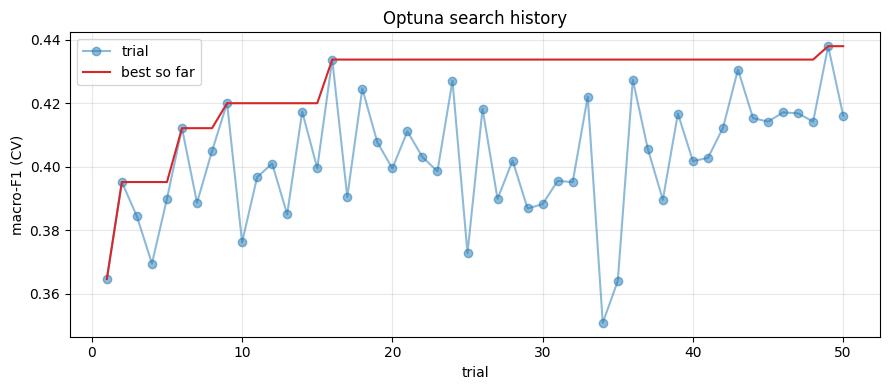

In [8]:
# Trial history plot — confirms the search is converging.
trial_vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(trial_vals)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(trial_vals) + 1), trial_vals, "o-", alpha=0.5, label="trial")
ax.plot(range(1, len(running_best) + 1), running_best, "-", color="#d62728", label="best so far")
ax.set_xlabel("trial"); ax.set_ylabel("macro-F1 (CV)")
ax.set_title("Optuna search history")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "tabnet_optuna_history.png", dpi=150)
plt.show()


## 5. Train final model with best hyperparameters

SMOTE is now applied once to the entire training set (not per fold). The
validation set drives early stopping. The test set is still untouched.


In [9]:
log.info("SMOTE on full training set ...")
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
log.info(f"SMOTE: {len(y_train)} -> {len(y_train_sm)}")
log.info(f"class counts after SMOTE: {pd.Series(y_train_sm).value_counts().sort_index().tolist()}")

final_model = make_tabnet(best_params, cat_idxs, cat_dims)
t0 = time.time()
final_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_train_sm, y_train_sm), (X_val, y_val)],
    eval_name=["train", "val"],
    eval_metric=["accuracy", "logloss"],
    max_epochs=MAX_EPOCHS, patience=PATIENCE,
    batch_size=BATCH_SIZE, virtual_batch_size=VBATCH_SIZE, drop_last=False,
)
log.info(f"final fit in {time.time() - t0:.1f}s")


21:02:10 [INFO] SMOTE on full training set ...
21:02:10 [INFO] SMOTE: 8620 -> 21867
21:02:10 [INFO] class counts after SMOTE: [7289, 7289, 7289]



Early stopping occurred at epoch 43 with best_epoch = 13 and best_val_logloss = 0.53257


21:02:45 [INFO] final fit in 35.1s


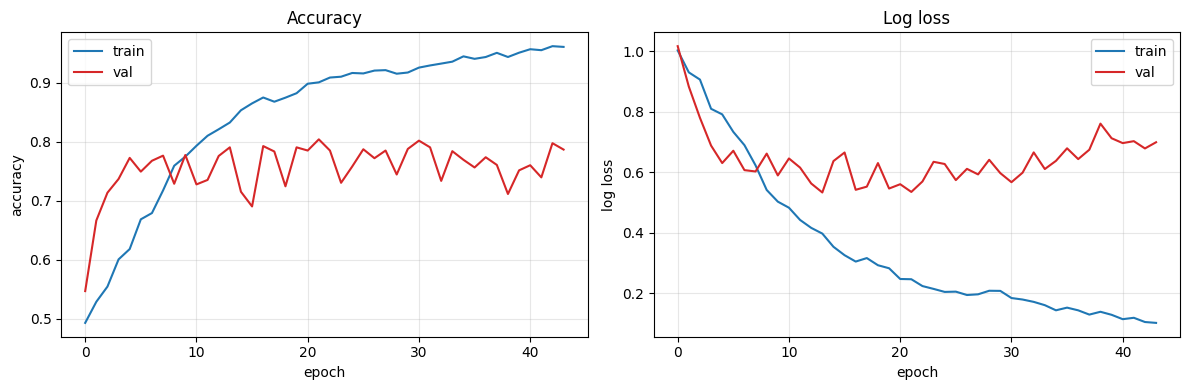

In [10]:
# Training curves — useful for diagnosing over/underfitting.
hist = final_model.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist["train_accuracy"], label="train", color="#1f77b4")
axes[0].plot(hist["val_accuracy"], label="val", color="#d62728")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist["train_logloss"], label="train", color="#1f77b4")
axes[1].plot(hist["val_logloss"], label="val", color="#d62728")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("log loss")
axes[1].set_title("Log loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "tabnet_training_curves.png", dpi=150)
plt.show()


## 6. Test set evaluation

=== Test set (argmax) ===
  accuracy           0.7760
  precision_macro    0.3794
  recall_macro       0.3956
  f1_macro           0.3789
  f1_weighted        0.7620
  roc_auc_ovr        0.6508

  classification report:
              precision    recall  f1-score   support

      Slight       0.85      0.89      0.87      1563
     Serious       0.21      0.13      0.16       261
       Fatal       0.08      0.17      0.11        24

    accuracy                           0.78      1848
   macro avg       0.38      0.40      0.38      1848
weighted avg       0.75      0.78      0.76      1848



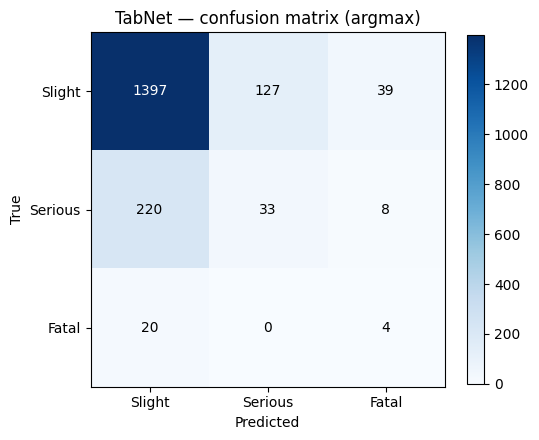

In [11]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

test_metrics = metric_block(y_test, y_pred, y_proba, label="Test set (argmax)")
cm = confusion_matrix(y_test, y_pred)
plot_confusion(cm, "TabNet — confusion matrix (argmax)",
               save_path=FIG_DIR / "tabnet_confusion_argmax.png")


## 7. Per-class threshold tuning

Argmax over predict_proba uses an implicit 1/3 threshold per class. For an
imbalanced 3-class problem, sweeping a one-vs-rest decision threshold per class
often improves recall on the rare class (Fatal). The plot below shows F1 vs
threshold for each class; the best per-class threshold is marked.

The tuned classifier predicts a class only if its probability exceeds the
tuned per-class threshold. If multiple classes pass, argmax breaks ties; if
none pass, argmax over predict_proba is used as the fallback.


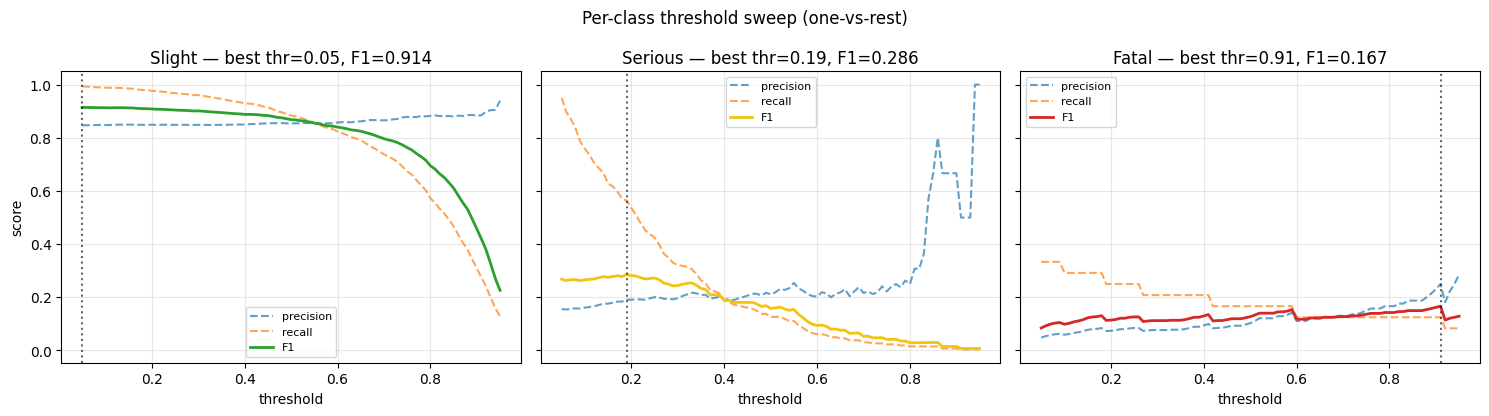

Best per-class thresholds: {'Slight': 0.05, 'Serious': 0.19, 'Fatal': 0.9099999999999999}


In [12]:
thresholds = np.linspace(0.05, 0.95, 91)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
best_thr = {}

for k, (name, color) in enumerate(zip(SEV_SHORT, SEVERITY_PALETTE)):
    f1s, pres, recs = [], [], []
    y_bin = (y_test == k).astype(int)
    for thr in thresholds:
        p_bin = (y_proba[:, k] >= thr).astype(int)
        f1s.append(f1_score(y_bin, p_bin, zero_division=0))
        pres.append(precision_score(y_bin, p_bin, zero_division=0))
        recs.append(recall_score(y_bin, p_bin, zero_division=0))

    f1s = np.array(f1s); pres = np.array(pres); recs = np.array(recs)
    best_idx = int(np.argmax(f1s))
    best_thr[name] = float(thresholds[best_idx])

    ax = axes[k]
    ax.plot(thresholds, pres, label="precision", color="#1f77b4", linestyle="--", alpha=0.7)
    ax.plot(thresholds, recs, label="recall",    color="#ff7f0e", linestyle="--", alpha=0.7)
    ax.plot(thresholds, f1s,  label="F1",        color=color, linewidth=2)
    ax.axvline(thresholds[best_idx], color="black", linestyle=":", alpha=0.6)
    ax.set_title(f"{name} — best thr={thresholds[best_idx]:.2f}, F1={f1s[best_idx]:.3f}")
    ax.set_xlabel("threshold")
    if k == 0: ax.set_ylabel("score")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Per-class threshold sweep (one-vs-rest)")
plt.tight_layout()
plt.savefig(FIG_DIR / "tabnet_threshold_sweep.png", dpi=150)
plt.show()
print("Best per-class thresholds:", best_thr)


=== Test set (threshold-tuned) ===
  accuracy           0.7911
  precision_macro    0.4347
  recall_macro       0.3922
  f1_macro           0.4051
  f1_weighted        0.7712
  roc_auc_ovr        0.6508

  classification report:
              precision    recall  f1-score   support

      Slight       0.85      0.91      0.88      1563
     Serious       0.22      0.14      0.17       261
       Fatal       0.23      0.12      0.16        24

    accuracy                           0.79      1848
   macro avg       0.43      0.39      0.41      1848
weighted avg       0.76      0.79      0.77      1848



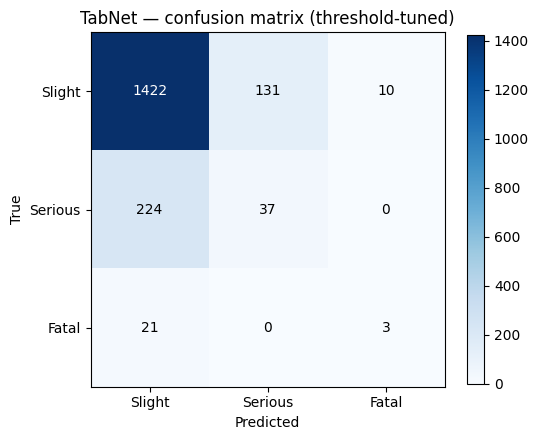

In [13]:
def predict_with_thresholds(proba, thr_map):
    """For each row, mark a class as candidate if its probability passes
    the per-class threshold; among candidates, pick the highest probability.
    If no class passes, fall back to argmax."""
    thr_arr = np.array([thr_map[n] for n in SEV_SHORT])
    above = proba >= thr_arr
    out = np.full(len(proba), -1, dtype=int)
    for i in range(len(proba)):
        if above[i].any():
            cand = np.where(above[i])[0]
            out[i] = cand[np.argmax(proba[i, cand])]
        else:
            out[i] = int(np.argmax(proba[i]))
    return out


y_pred_tuned = predict_with_thresholds(y_proba, best_thr)
tuned_metrics = metric_block(y_test, y_pred_tuned, y_proba,
                             label="Test set (threshold-tuned)")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plot_confusion(cm_tuned, "TabNet — confusion matrix (threshold-tuned)",
               save_path=FIG_DIR / "tabnet_confusion_tuned.png")


## 8. Save model and metrics

In [14]:
# TabNet's save_model writes path.zip with weights + topology.
model_path = MODEL_DIR / "tabnet_best"
final_model.save_model(str(model_path))

# Save the encoder / scaler / feature order alongside so inference is reproducible.
import joblib
joblib.dump({
    "encoder": encoder, "scaler": scaler,
    "cat_cols": cat_cols, "num_cols": num_cols,
    "cat_idxs": cat_idxs, "cat_dims": cat_dims,
    "best_params": best_params,
    "best_thresholds": best_thr,
}, MODEL_DIR / "tabnet_artifacts.joblib")

results = {
    "best_params": best_params,
    "best_thresholds": best_thr,
    "test_argmax": test_metrics,
    "test_threshold_tuned": tuned_metrics,
    "confusion_argmax": cm.tolist(),
    "confusion_tuned": cm_tuned.tolist(),
    "n_train": int(len(y_train)), "n_val": int(len(y_val)), "n_test": int(len(y_test)),
}
RESULTS.write_text(json.dumps(results, indent=2))
log.info(f"Wrote {RESULTS}")
log.info(f"Saved model to {model_path}.zip")


21:02:46 [INFO] Wrote /home/thsondev/Projects/crash-severity-tabnet-stacking/outputs/tabnet_metrics.json
21:02:46 [INFO] Saved model to /home/thsondev/Projects/crash-severity-tabnet-stacking/models/tabnet_best.zip


Successfully saved model at /home/thsondev/Projects/crash-severity-tabnet-stacking/models/tabnet_best.zip


## 9. SHAP interpretation

KernelExplainer is model-agnostic so it works with TabNet. SHAP values are
computed against a small background sample drawn from the (SMOTE-augmented)
training set, evaluated on a sample of test rows for tractable runtime.

The new SHAP API returns an `(n_samples, n_features, n_classes)` array; we
slice out per-class arrays to feed into `shap.summary_plot`.


In [15]:
rng = np.random.default_rng(SEED)
bg_idx = rng.choice(len(X_train_sm), size=min(SHAP_BG, len(X_train_sm)), replace=False)
background = X_train_sm[bg_idx]

eval_idx = rng.choice(len(X_test), size=min(SHAP_EVAL, len(X_test)), replace=False)
X_shap = X_test[eval_idx]

log.info(f"SHAP: background={len(background)}, eval={len(X_shap)}")
explainer = shap.KernelExplainer(final_model.predict_proba, background)
t0 = time.time()
shap_values = explainer.shap_values(X_shap, nsamples=100)
log.info(f"SHAP done in {time.time() - t0:.1f}s; shape={np.array(shap_values).shape}")


21:02:46 [INFO] SHAP: background=100, eval=200
100%|██████████| 200/200 [00:24<00:00,  8.10it/s]
21:03:11 [INFO] SHAP done in 24.7s; shape=(200, 26, 3)


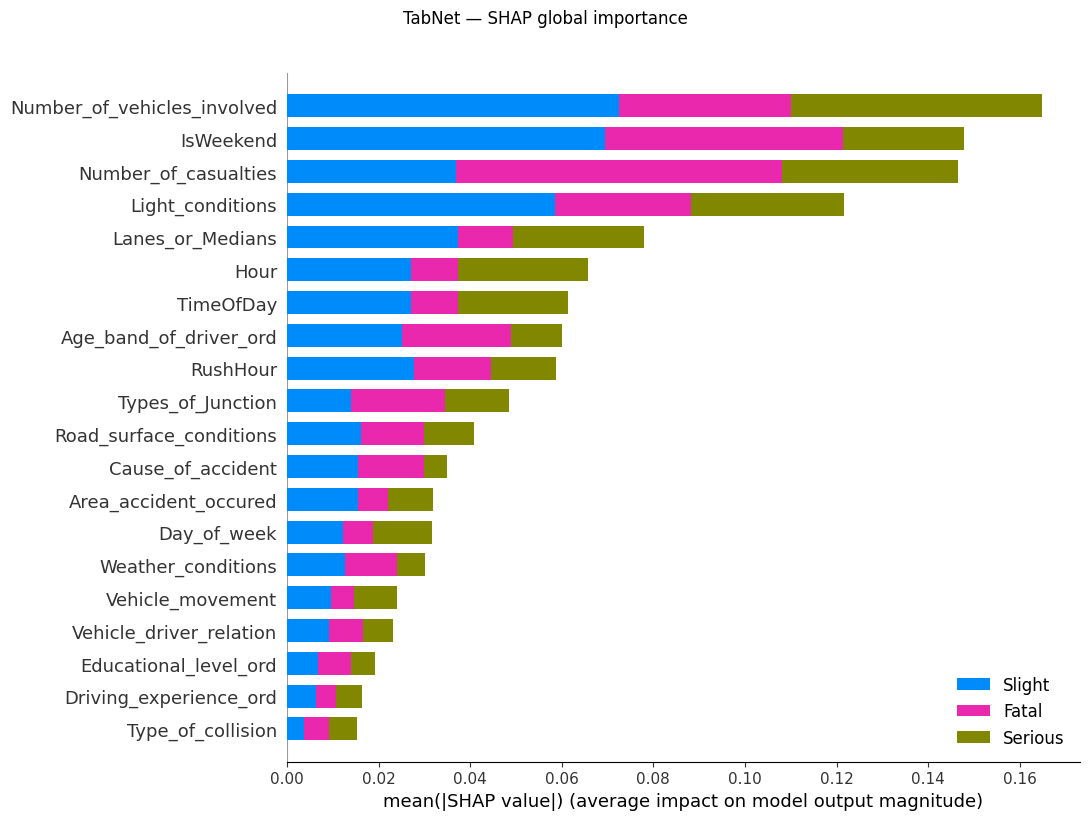

In [16]:
# Summary plot (bar) — global feature importance across all classes.
# Convert (N, F, C) -> list of (N, F) per class for shap.summary_plot.
shap_per_class = [shap_values[:, :, k] for k in range(3)]

shap.summary_plot(shap_per_class, X_shap, feature_names=feature_names,
                  plot_type="bar", class_names=SEV_SHORT, show=False, plot_size=(11, 8))
fig = plt.gcf(); fig.suptitle("TabNet — SHAP global importance", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "tabnet_shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()


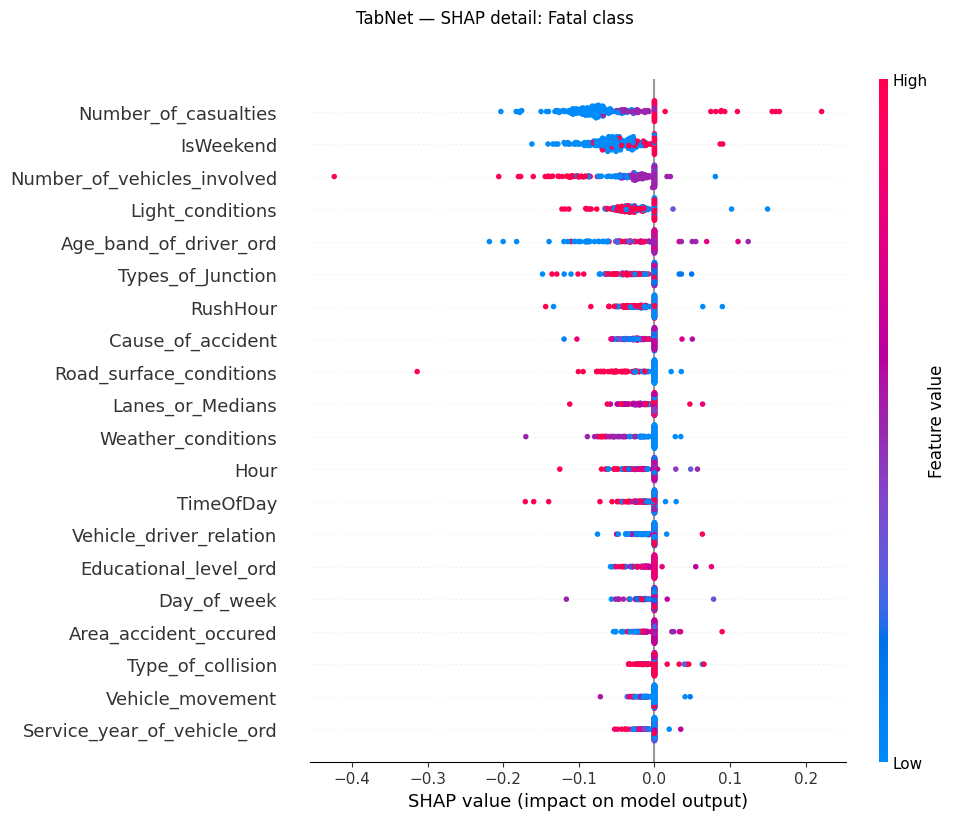

In [17]:
# Dot plot for the Fatal class — where the model concentrates its risk signal.
fatal_idx = SEV_SHORT.index("Fatal")
shap.summary_plot(shap_per_class[fatal_idx], X_shap, feature_names=feature_names,
                  plot_type="dot", show=False, plot_size=(10, 8))
fig = plt.gcf(); fig.suptitle("TabNet — SHAP detail: Fatal class", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "tabnet_shap_dot_fatal.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Post-hoc / sensitivity analysis

The original paper simulated a policy intervention by editing one feature
(e.g. lighting) on the test set and observing the change in SHAP distribution.
Here we replicate that idea on `Light_conditions`: replace every value with
the most-common 'safe' lighting condition and see how the model's predicted
Fatal probability shifts.


Mean predicted probability shift after setting Light_conditions='Daylight':
  Slight   original=0.7614  intervened=0.7837  delta=+0.0223
  Serious  original=0.2075  intervened=0.1915  delta=-0.0160
  Fatal    original=0.0311  intervened=0.0248  delta=-0.0063


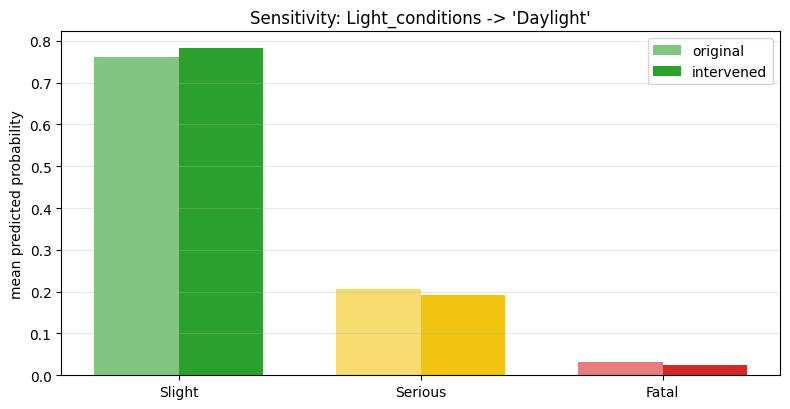

In [18]:
# Post-hoc: simulate a policy where every accident occurred in 'Daylight'.
# Replace Light_conditions in the test set, re-encode (using fitted encoder),
# and compare predicted probabilities.
target_feature = "Light_conditions"
intervene_value = "Daylight"

if intervene_value not in df["Light_conditions"].unique():
    intervene_value = df["Light_conditions"].mode().iloc[0]
    log.info(f"'Daylight' not in data; intervening with '{intervene_value}' instead")

df_test_int = df_test.copy()
df_test_int[target_feature] = intervene_value
X_test_int, _, _ = encode(df_test_int, cat_cols, num_cols, encoder, scaler, fit=False)
proba_int = final_model.predict_proba(X_test_int)

orig_mean = y_proba.mean(axis=0)
intv_mean = proba_int.mean(axis=0)
delta = intv_mean - orig_mean

print(f"Mean predicted probability shift after setting {target_feature}='{intervene_value}':")
for name, o, i, d in zip(SEV_SHORT, orig_mean, intv_mean, delta):
    print(f"  {name:<8s} original={o:.4f}  intervened={i:.4f}  delta={d:+.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(3); w = 0.35
ax.bar(x - w/2, orig_mean, width=w, color=SEVERITY_PALETTE, label="original", alpha=0.6)
ax.bar(x + w/2, intv_mean, width=w, color=SEVERITY_PALETTE, label="intervened", alpha=1.0)
ax.set_xticks(x); ax.set_xticklabels(SEV_SHORT)
ax.set_ylabel("mean predicted probability")
ax.set_title(f"Sensitivity: {target_feature} -> '{intervene_value}'")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "tabnet_sensitivity_light.png", dpi=150)
plt.show()


## 11. Summary

- Best Optuna macro-F1 (CV): see log above.
- Argmax test metrics: standard prediction.
- Threshold-tuned test metrics: usually better recall on Serious/Fatal at the
  cost of some precision.
- Saved artefacts: `models/tabnet_best.zip`, `models/tabnet_artifacts.joblib`,
  `outputs/tabnet_metrics.json`, and figures under `outputs/figures/`.

This pipeline is parallel in structure to `stacking-ensemble.ipynb`, so the
two model families can be compared side-by-side on the same train/val/test split.
